**Классификация музыки по жанрам**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import librosa
import librosa.display
import IPython.display as ipd
from sklearn import preprocessing

In [2]:
!pip install kaggle

import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification --unzip

In [3]:
folders = [folder for folder in os.listdir('/content/Data/genres_original')]
folders

['metal',
 'jazz',
 'rock',
 'reggae',
 'country',
 'disco',
 'hiphop',
 'pop',
 'blues',
 'classical']

**Звук**(sound): последовательность вибраций при различной силе давления

**Частота дискретизации** sr — это количество выборок аудио, передаваемых в секунду

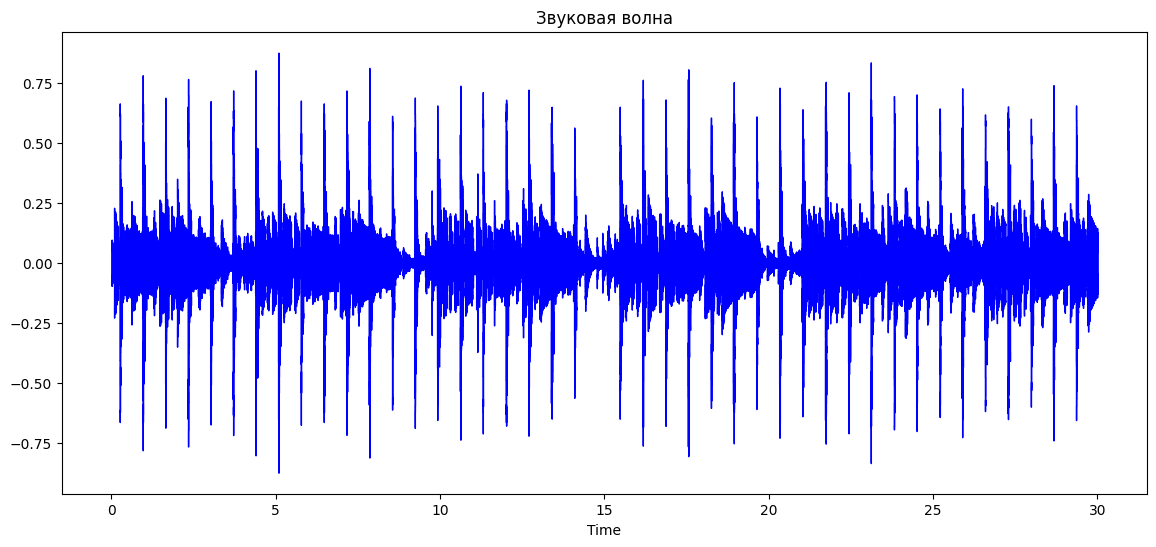

In [4]:
sound, sr = librosa.load('/content/Data/genres_original/reggae/reggae.00036.wav')
audio_file, _ = librosa.effects.trim(sound)

plt.figure(figsize = (14, 6))
librosa.display.waveshow(y = audio_file, sr = sr, color = "blue")
plt.title("Звуковая волна");

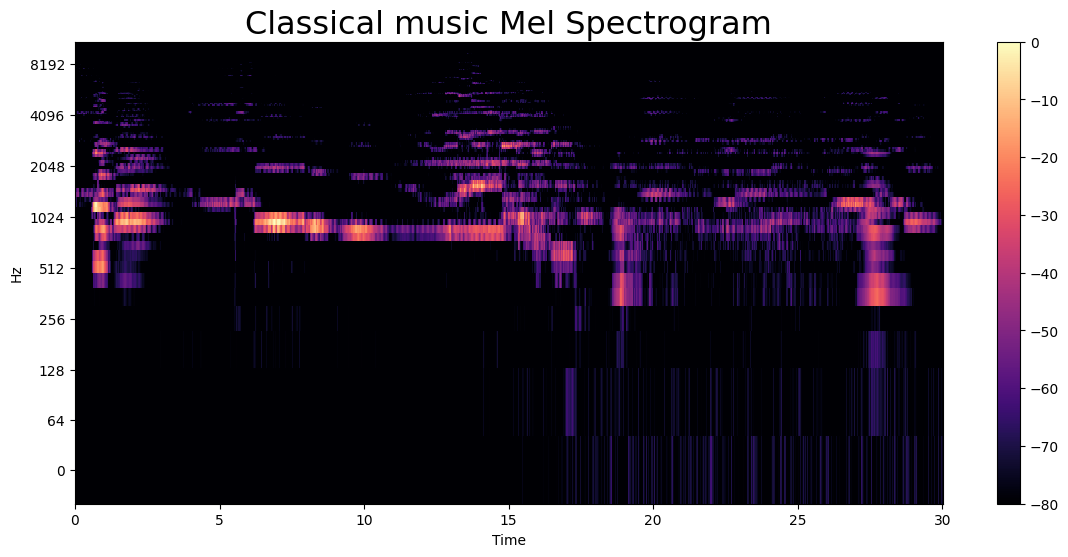

In [5]:
sound_classical, sr_classical = librosa.load('/content/Data/genres_original/classical/classical.00036.wav')
sound_classical, _ = librosa.effects.trim(sound_classical)
hop_length = 512

S = librosa.feature.melspectrogram(y=sound_classical, sr=sr_classical, hop_length=hop_length)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize = (14, 6))
librosa.display.specshow(S_DB, sr=sr_classical, hop_length=hop_length, x_axis = 'time', y_axis = 'log',);
plt.colorbar();
plt.title("Classical music Mel Spectrogram", fontsize = 23);

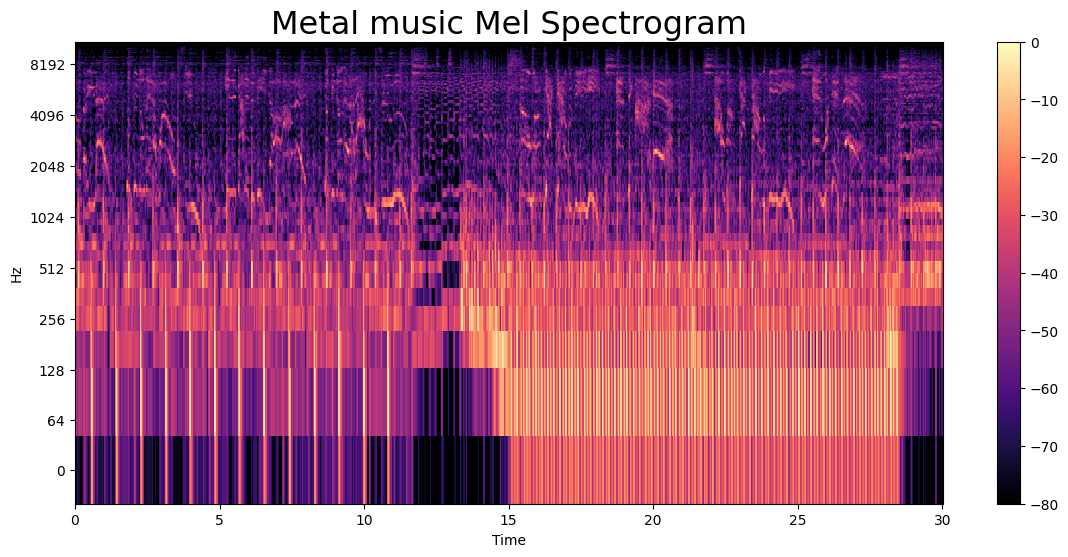

In [6]:
sound_metal, sr_metal = librosa.load('/content/Data/genres_original/metal/metal.00036.wav')
sound_metal, _ = librosa.effects.trim(sound_metal)
hop_length = 512

S = librosa.feature.melspectrogram(y=sound_metal, sr=sr_metal, hop_length=hop_length)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize = (14, 6))
librosa.display.specshow(S_DB, sr=sr_metal, hop_length=hop_length, x_axis = 'time', y_axis = 'log',);
plt.colorbar();
plt.title("Metal music Mel Spectrogram", fontsize = 23);

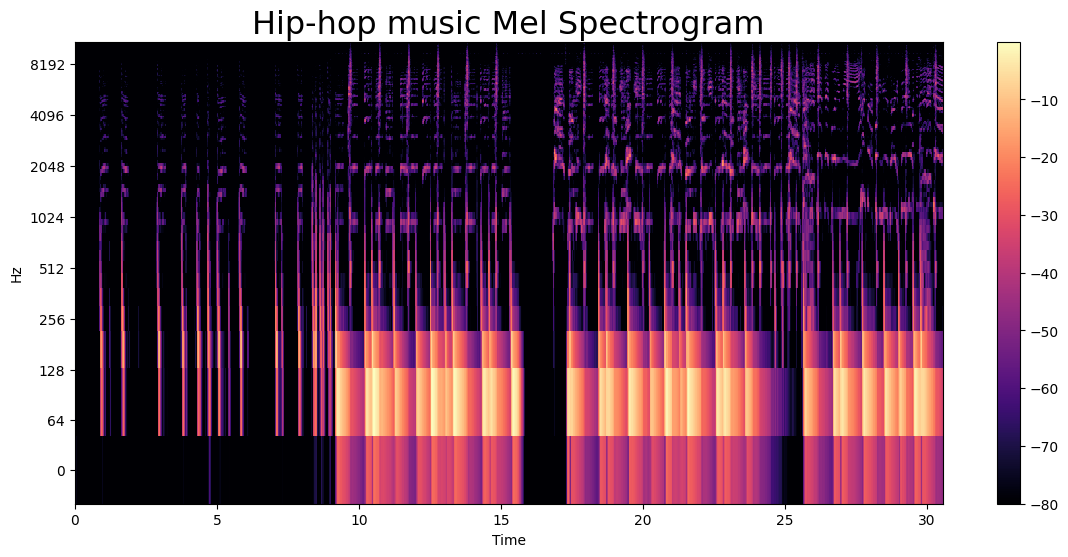

In [7]:
sound, sr = librosa.load('/content/Data/genres_original/hiphop/hiphop.00036.wav')
sound, _ = librosa.effects.trim(sound)
hop_length = 512

S = librosa.feature.melspectrogram(y=sound, sr=sr, hop_length=hop_length)
S_DB = librosa.amplitude_to_db(S, ref=np.max)
plt.figure(figsize = (14, 6))
librosa.display.specshow(S_DB, sr=sr, hop_length=hop_length, x_axis = 'time', y_axis = 'log',);
plt.colorbar();
plt.title("Hip-hop music Mel Spectrogram", fontsize = 23);

У металла высокая энергия в широком диапазоне частот.

Более яркие спектры в низких и средних частотах из-за бас-гитар и ударных.

Высокую плотность энергии в высоких частотах из-за электрогитар.

У классической музыки более мягкое распределение и низкая плотность в высоких частотах

In [8]:
S_metal = librosa.feature.melspectrogram(y=sound_metal, sr=sr_metal)
energy_metal = np.sum(S_metal)

S_classical = librosa.feature.melspectrogram(y=sound_classical, sr=sr_classical)
energy_classical = np.sum(S_classical)

print("Энергия по частотам для металла:", energy_metal)
print("Энергия по частотам для классики:", energy_classical)

Энергия по частотам для металла: 441438.25
Энергия по частотам для классики: 17298.646


In [9]:
df = pd.read_csv('/content/Data/features_3_sec.csv')
df.head(3)

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues


<ipython-input-10-7a2094aa6f10>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="tempo", data=avg_tempo, palette="Set2")


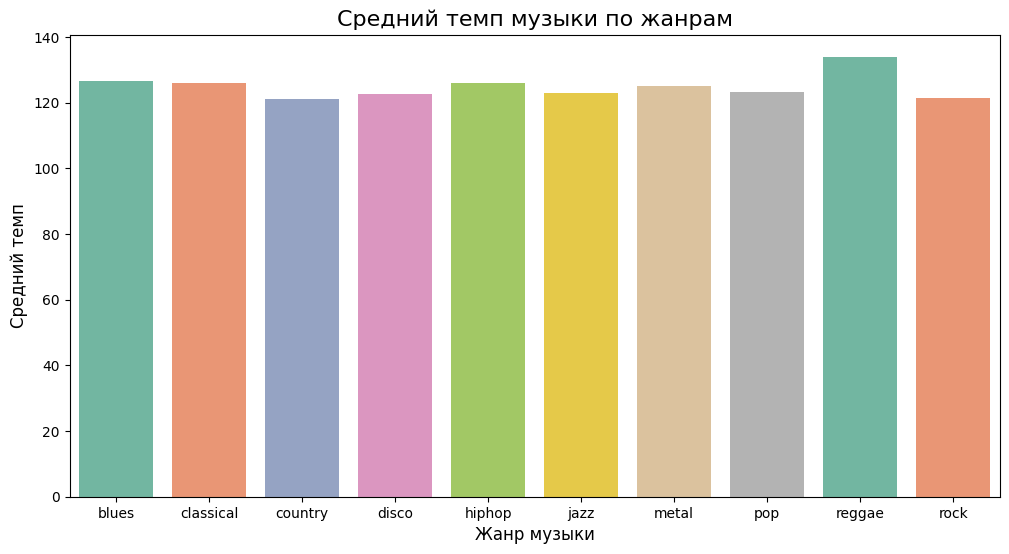

In [10]:
avg_tempo = df.groupby("label")["tempo"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="label", y="tempo", data=avg_tempo, palette="Set2")
plt.title("Средний темп музыки по жанрам", fontsize=16)
plt.xlabel("Жанр музыки", fontsize=12)
plt.ylabel("Средний темп", fontsize=12)
plt.show()


In [11]:
df = df.iloc[0:, 1:]

y = df['label']
X = df.drop(columns='label')

In [12]:
min_max_scaler = preprocessing.MinMaxScaler()
X.loc[:, :] = min_max_scaler.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
round(accuracy, 2)

0.81

In [23]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05)
xgb.fit(X_train, y_train_encoded)
y_pred = xgb.predict(X_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)
accuracy = accuracy_score(y_pred_labels, y_test)
round(accuracy, 2)

0.9

In [24]:
rforest = RandomForestClassifier(n_estimators=1000, max_depth=10)
rforest.fit(X_train, y_train)
y_pred = rforest.predict(X_test)
accuracy = accuracy_score(y_pred, y_test)
round(accuracy, 2)

0.81